In [1]:
import matplotlib.pyplot as plt
plt.rc('text', usetex = True)

from ast import literal_eval as liteval 
import numpy as np
import os
import math as m
import scipy.optimize as sciopt

import sys
sys.path.insert(0, os.getcwd().removesuffix("/psps"))
sys.path.insert(0, os.getcwd().removesuffix("/ashwin_md/ld_analysis/log/psps") + "/code/py/Math")
import file_utils
from file_utils import readData, float2latex
from fitdat import theil_sen, ax_pow_b
sys.path.pop(0)

dirpath = "//media/ashwin/Expansion/ashwin_md/psps"
figpath = "/home/ashwin/Desktop/ashwin_md/LD/imgs/Oct2025/"

colors = ["darkorange", "crimson", "#2544D0", "olive", "orangered", "#2544D0", "k"]

In [2]:
# Objective function
def func(t, args):
    t = t[0]
    tau = args[0]
    Fd = args[1]
    del_x = args[2]
    
    exp_t = m.exp(-t/tau)
    val = (Fd*tau*(t - tau*(1 - exp_t)))**2 + 2*t*tau + tau*tau*(-3 + 4*exp_t - exp_t*exp_t) - del_x*del_x
    return(val)


 0.475
0.001 4.652063 The solution converged.
0.002 2.327547 The solution converged.
0.003 1.553382 The solution converged.
0.004 1.166805 The solution converged.
0.005 0.935263 The solution converged.
0.006 0.781239 The solution converged.
0.007 0.67151 The solution converged.
0.008 0.589466 The solution converged.
0.009 0.525878 The solution converged.
0.01 0.47521 The solution converged.
0.02 0.252763 The solution converged.
0.03 0.185287 The solution converged.
0.04 0.155867 The solution converged.
0.05 0.140473 The solution converged.
0.06 0.131286 The solution converged.
0.07 0.125259 The solution converged.
0.08 0.121025 The solution converged.
0.09 0.117896 The solution converged.
0.1 0.115494 The solution converged.
0.2 0.105724 The solution converged.
0.3 0.102816 The solution converged.
0.4 0.101423 The solution converged.
0.5 0.100605 The solution converged.
0.6 0.100067 The solution converged.
0.7 0.099687 The solution converged.
0.8 0.099404 The solution converged.
0.9 0

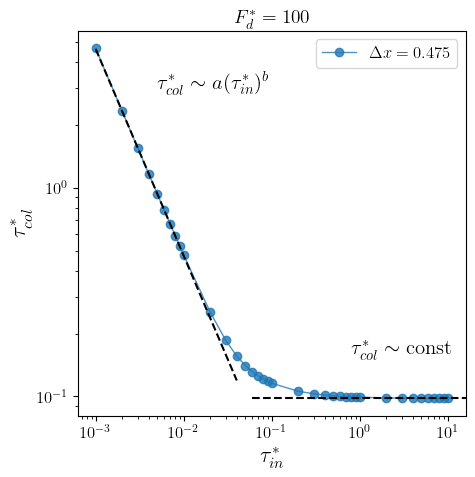

In [25]:
# Plot of collision time vs inertial time for fixed Fd and varying characteristic separation lengths

# List of inertial times
tau_list = [1e-3]
ctr = -3
while(ctr < 1):
    for i in range(1, 10, 1):
        tau_list.append(round((i+1)*10**(ctr), 5))
    ctr += 1

fig, ax = plt.subplots(figsize = (5, 5))
ms = 6
lw = 1

Fd = 100
rho = 0.45

fac_list = range(5, 6, 1)
del_x = [0.1*i/m.sqrt(rho) for i in fac_list]
del_x = [0.475]

for j in range(len(del_x)):
    print("\n", round(del_x[j], 3))
    
    tau_col = []
    for i in range(len(tau_list)):
        output = sciopt.fsolve(func, x0 = 1e-1, args = [tau_list[i], Fd, del_x[j]], xtol = 1e-12, full_output = 1)
        tau_col.append(round(output[0][0], 6))
        message = output[3]

        print(tau_list[i], tau_col[i], message)
    
    ax.loglog(tau_list, tau_col, "o-", ms = ms, lw = lw, label = r"$\Delta x = {fac}$".format(fac = del_x[j]), alpha = 0.8)

    ax.axhline(y = tau_col[-1], xmin = 0.45, xmax = 1, ls = "--", color = "k", lw = 1.5)

    x = [m.log(i) for i in tau_list[0:8]]
    y = [m.log(i) for i in tau_col[0:8]]
    [b, a] = theil_sen(x, y)
    a = m.exp(a)
    print(a, b)

    x = tau_list[0:13]
    y = [a*(i**b) for i in x]    

    ax.loglog(x, y, "k--", lw = 1.5)

ax.text(x = 5e-3, y = 3, s = r"$\tau_{col}^* \sim a(\tau_{in}^*)^b$", fontsize = 15)
ax.text(x = 0.8, y = 0.16, s = r"$\tau_{col}^* \sim \textrm{const}$", fontsize = 15)

ax.set_xlabel(r"$\tau_{in}^*$", fontsize = 16)
ax.set_ylabel(r"$\tau_{col}^*$", fontsize = 16)
ax.tick_params(axis = "both", which = "major", labelsize = 12)
ax.set_title(r"$F_d^*=100$", fontsize = 14, loc = "center")
ax.legend(fontsize = 12, ncols = 2)

# fig.savefig(os.path.join(figpath, "tau_col_Fd_100_tau_all.png"), dpi = 500, bbox_inches = "tight")

1e-1 20 0.314239 The solution converged.
1e-1 40 0.201256 The solution converged.
1e-1 60 0.15665 The solution converged.
1e-1 80 0.131755 The solution converged.
1e-1 100 0.115494 The solution converged.
1e-1 150 0.091374 The solution converged.
1e-1 200 0.077656 The solution converged.
1e-1 250 0.068571 The solution converged.
1e-1 300 0.062006 The solution converged.
1e-1 350 0.056986 The solution converged.
1e-1 400 0.052992 The solution converged.
1e-1 450 0.049717 The solution converged.
1e-1 500 0.046972 The solution converged.
1e-1 550 0.044627 The solution converged.
1e-1 600 0.042595 The solution converged.
1e-1 650 0.040813 The solution converged.
1e-1 700 0.039233 The solution converged.
1e-1 750 0.03782 The solution converged.
1e-1 800 0.036548 The solution converged.
1e-1 850 0.035393 The solution converged.
1e-1 900 0.03434 The solution converged.
1e-1 950 0.033373 The solution converged.
1e-1 1000 0.032483 The solution converged.

23 23
1.4104643832654806 -0.546646


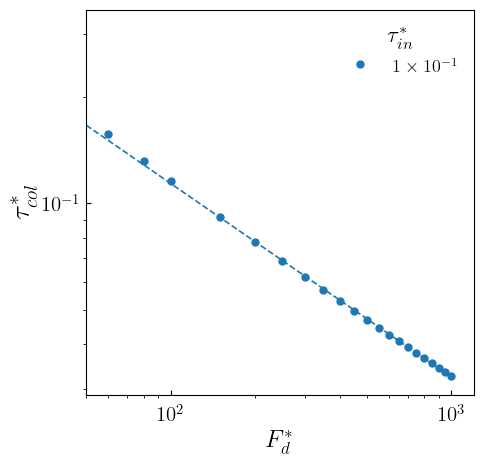

In [5]:
# Plot of collision time versus driving force for a fixed tau_in

del_x = 0.475

tau_list = ["1e-1"]
Fd_list = list(np.arange(100, 1000 + 50, 50))
Fd_list = Fd_list + list(np.arange(20, 100, 20))
Fd_list.sort()

fig, ax = plt.subplots(figsize = (5, 5))

for i in range(len(tau_list)):
    tau_col = []

    for j in range(len(Fd_list)):
        output = sciopt.fsolve(func, x0 = 0.05, args = [liteval(tau_list[i]), Fd_list[j], del_x], xtol = 1e-12, full_output = 1)
        tau_col.append(round(output[0][0], 6))
        message = output[3]

        print(tau_list[i], Fd_list[j], tau_col[j], message)

    line, = ax.loglog(Fd_list, tau_col, "o", lw = 1.2, ms = 5, label = r"${tau}$".format(tau = float2latex([tau_list[i]])))
    l_color = line.get_color()

    x = [m.log(fd) for fd in Fd_list[0::]]
    y = [m.log(tau) for tau in tau_col[0::]]

    print()
    print(len(x), len(y))

    [b, a] = theil_sen(x, y)
    a = m.exp(a)

    print(a, b)

    y_th = [a*(fd**b) for fd in Fd_list]

    ax.loglog(Fd_list, y_th, "--", color = l_color, lw = 1.2)

ax.set(xlim = (50, 1.2e3))
ax.set_xlabel(r"$F_d^*$", fontsize = 18)
ax.set_ylabel(r"$\tau_{col}^*$", fontsize = 20)
ax.tick_params(axis = "both", which = "major", direction = "in", labelsize = 15)
ax.tick_params(axis = "x", which = "major", pad = 8)

leg = ax.legend(title = r"$\tau_{in}^*$", fontsize = 13, ncols = 2, frameon = False)
leg.get_title().set_fontsize("17")

# fig.savefig(os.path.join(figpath, "tau_col_tau_in_all.png"), dpi = 500, bbox_inches = "tight")


 0

 100

 200

 300

 400

 500

 600

 700

 800

 900

 1000

 1100

 1200

 1300

 1400

 1500


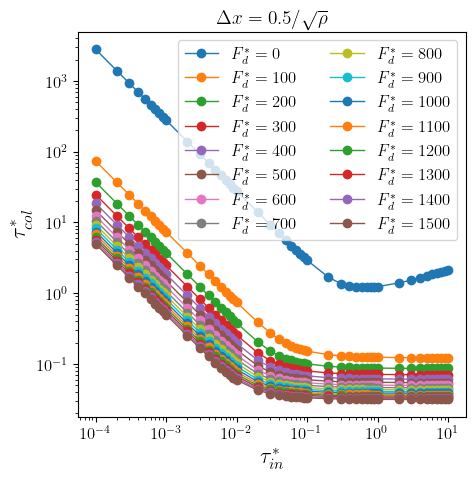

In [7]:
# Plot of collision time vs inertial time for fixed separation length and varying driving forces

fig, ax = plt.subplots(figsize = (5, 5))
ms = 6
lw = 1

rho = 0.45
del_x = 0.5/m.sqrt(rho)

Fd = np.arange(0, 830, 100)

for j in range(len(Fd)):
    print("\n", Fd[j])
    
    tau_col = []
    for i in range(len(tau_list)):
        output = sciopt.fsolve(func, x0 = 1e0, args = [tau_list[i], Fd[j], del_x], xtol = 1e-12, full_output = 1)
        tau_col.append(round(output[0][0], 6))
        message = output[3]

        # print(tau_list[i], tau_col[i], message)
    
    ax.loglog(tau_list, tau_col, "o-", ms = ms, lw = lw, label = r"$F_d^* = {fd}$".format(fd = str(Fd[j])), alpha = 1)

    # ax.axhline(y = tau_col[-1], xmin = 0.4, xmax = 1, ls = "--", color = "k", lw = 1.5)

    # x = [m.log(i) for i in tau_list[0:8]]
    # y = [m.log(i) for i in tau_col[0:8]]
    # [b, a] = theil_sen(x, y)
    # a = m.exp(a)
    # print(a, b)

    # x = tau_list[0:14]
    # y = [a*(i**b) for i in x]    

    # ax.loglog(x, y, "k--", lw = 1.5)

# ax.text(x = 5e-3, y = 3, s = r"$\tau_{col}^* \sim a(\tau_{in}^*)^b$", fontsize = 15)
# ax.text(x = 0.8, y = 0.16, s = r"$\tau_{col}^* \sim \textrm{const}$", fontsize = 15)

ax.set_xlabel(r"$\tau_{in}^*$", fontsize = 16)
ax.set_ylabel(r"$\tau_{col}^*$", fontsize = 16)
ax.tick_params(axis = "both", which = "major", labelsize = 12)
ax.set_title(r"$\Delta x = 0.5/\sqrt{\rho}$", fontsize = 14, loc = "center")
ax.legend(fontsize = 12, ncols = 2)

# fig.savefig(os.path.join(figpath, "tau_col_dx_all.png"), dpi = 500, bbox_inches = "tight")

Text(0.5, 1.0, '$F_d^* = 100$')

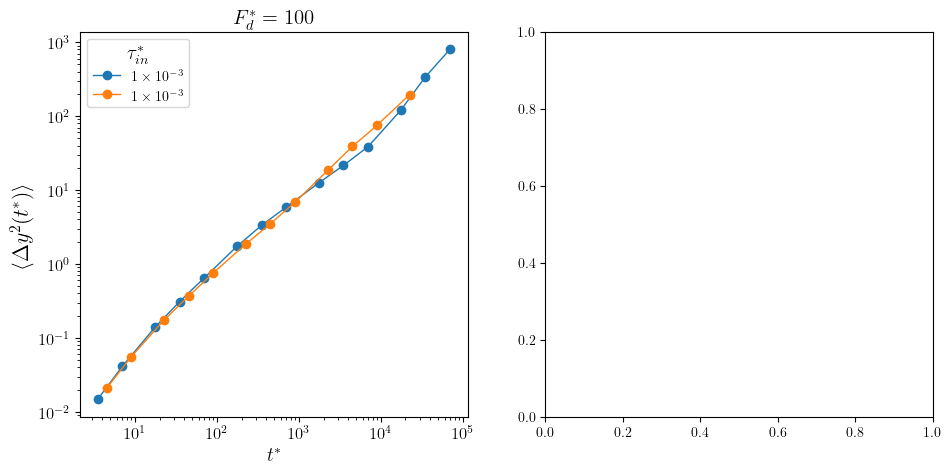

In [18]:
# Plot of MSD_yy versus time

tau_list = ["1e-3"]
tau_in = [liteval(i) for i in tau_list]
Deff = []
Deff_norm = []
locus = [[], []]

lw = 1
ms = 6

file_paths = []
for i in range(len(tau_list)):
    file_paths.append(os.path.join(dirpath, "Fd100", "tau_{tau}".format(tau = tau_list[i]), "tau_col_2", "msd.dat"))

file_paths.append(os.path.join(dirpath, "tau_1e-3/test2/msd.dat"))
tau_list.append("1e-3")

fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (11, 5))

for i in range(len(file_paths)):
    [data, _] = readData(file_paths[i], 1)
    time = data[0]
    msd_yy = data[4]

    locus[0].append(time[1])
    locus[1].append(msd_yy[1])

    Deff.append(round(0.5*(msd_yy[1] - msd_yy[0])/((time[1] - time[0])), 4))
    Deff_norm.append(round(0.5*(msd_yy[1] - msd_yy[0])/(liteval(tau_list[i])*(time[1] - time[0])), 4))

    ax1.loglog(time, msd_yy, "o-", ms = ms, lw = lw, label = "${tau}$".format(tau = float2latex([tau_list[i]])))   

# ax1.loglog(locus[0], locus[1], "k--", lw = lw)

ax1.set_xlabel(r"$t^*$", fontsize = 14)
ax1.set_ylabel(r"$\langle\Delta y^2(t^*)\rangle$", fontsize = 16)
ax1.tick_params(axis = "both", which = "major", labelsize = 12)
leg = ax1.legend(title = r"$\tau_{in}^*$", ncols = 1, fontsize = 10)
leg.get_title().set_fontsize("14")
ax1.set_title(r"$F_d^* = 100$", fontsize = 15)

# print(Deff)
# print(Deff_norm)

# ax2_t = ax2.twinx()

# lines = []
# line, = ax2.loglog(tau_in, Deff, "o-", color = colors[2], lw = lw, ms = ms, label = r"$D_{\textrm{eff}}$")
# lines.append(line)

# line, = ax2_t.semilogx(tau_in, Deff_norm, "o-", color = colors[1], lw = lw, ms = ms, label = r"$D_{\textrm{eff}}/D_0$")
# lines.append(line)

# ax2.set_xlabel(r"$\tau_{in}^*$", fontsize = 16)
# ax2.set_ylabel(r"$D_{\textrm{eff}}$", fontsize = 16)
# ax2.tick_params(axis = "both", which = "major", labelsize = 12)
# ax2.legend(handles = lines, fontsize = 12)

# ax2_t.set(ylim = (3, 7))
# ax2_t.set_ylabel(r"$D_{\textrm{eff}}/D_0$", fontsize = 16)
# ax2_t.tick_params(axis = "both", which = "major", labelsize = 12)

# plt.subplots_adjust(wspace = 0.25)

# fig.savefig(os.path.join(figpath, "msd_time_Fd100.png"), dpi = 500, bbox_inches = "tight")

[0.00295, 0.00594, 0.01468, 0.02923, 0.05606, 0.08172, 0.10703, 0.1305, 0.16468, 0.19744, 0.22863, 0.26072, 0.29925, 0.7807, 2.24763, 3.85662]


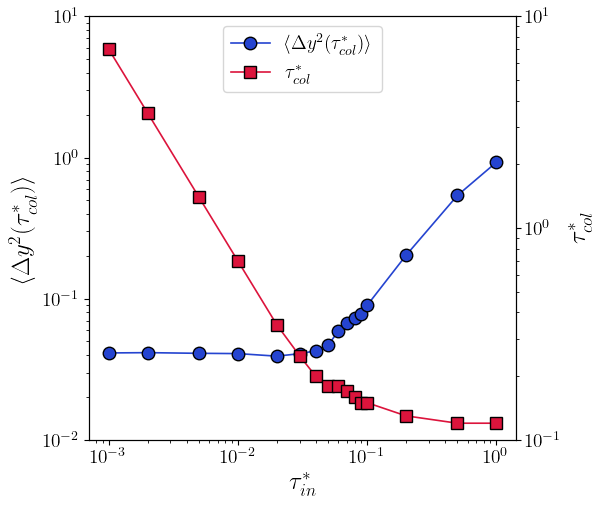

In [24]:
# Plot of MSD_yy vs inertial time at constant Fd = 100

tau_list = ["1e-3", "2e-3", "5e-3", "1e-2", "2e-2", "3e-2", "4e-2", "5e-2", "6e-2", "7e-2", "8e-2", "9e-2", "1e-1", "2e-1", "5e-1", "1e0"]

fig, ax = plt.subplots(figsize = (5.5, 5.5))
ms = 9
lw = 1.2

fpath = os.path.join(dirpath, "Fd100", "msd_all.dat")

[data, _] = readData(fpath, 1)
tau_in = data[0]
tau_col = data[1]
MSD_xx = data[3]
MSD_yy = data[4]
Deff = [round(MSD_yy[i]/(2*tau_col[i]), 5) for i in range(len(tau_in))]

print(Deff)

ax_t = ax.twinx()

lines = []

line, = ax.loglog(tau_in, MSD_yy, "o-", ms = ms, lw = lw, color = colors[2], mec = "k", mew = 1, 
                  label = r"$\langle\Delta y^2(\tau_{col}^*)\rangle$")
lines.append(line)
# line, = ax.loglog(tau_in, Deff, "o-", ms = ms, lw = lw, color = "purple", mec = "k", mew = 1, label = r"$D_{\textrm{eff}}$")
# lines.append(line)

line, = ax_t.loglog(tau_in, tau_col, "s-", ms = ms, lw = lw, color = colors[1], mec = "k", mew = 1, label = r"$\tau_{col}^*$")
lines.append(line)

ax.set(ylim = (1e-2, 1e1))
ax.set_xlabel(r"$\tau_{in}^*$", fontsize = 18)
ax.set_ylabel(r"$\langle\Delta y^2(\tau_{col}^*)\rangle$", fontsize = 18)
ax.tick_params(axis = "both", which = "major", labelsize = 14)

ax_t.set(ylim = (1e-1, 1e1))
ax_t.set_ylabel(r"$\tau_{col}^*$", fontsize = 18)
ax_t.tick_params(axis = "both", which = "major", labelsize = 14)

ax.legend(handles = lines, fontsize = 14, loc = "upper center")

# fig.savefig(os.path.join(figpath, "msd_tau_Fd100.png"), dpi = 500, bbox_inches = "tight")